In [1]:
!pwd
%cd ..

/home/banashree/neural-search/alpha_zero
/home/banashree/neural-search


/home/banashree/neural-search/venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:

import os

# This forces OpenMP to use 1 single thread, which is needed to
# prevent contention between multiple process.
os.environ['OMP_NUM_THREADS'] = '1'
# Tell numpy to only use one core.
os.environ['MKL_NUM_THREADS'] = '1'


import multiprocessing as mp
import sys
from absl import flags

import numpy as np
import torch
from torch.optim.lr_scheduler import MultiStepLR

FLAGS = flags.FLAGS

flags.DEFINE_integer('board_size', 9, 'Board size for Go.')
flags.DEFINE_float('komi', 7.5, 'Komi rule for Go.')
flags.DEFINE_integer(
    'num_stack',
    8,
    'Stack N previous states, the state is an image of N x 2 + 1 binary planes.',
)
flags.DEFINE_integer('num_res_blocks', 6, 'Number of residual blocks in the neural network.')
flags.DEFINE_integer('num_filters_resnet', 128, 'Number of filters for the conv2d layers in the neural network.')
flags.DEFINE_integer(
    'num_fc_units',
    128,
    'Number of hidden units in the linear layer of the neural network.',
)

flags.DEFINE_integer(
    'num_simulations',
    200,
    'Number of simulations per MCTS search, this applies to both self-play and evaluation processes.',
)

flags.DEFINE_integer(
    'num_parallel',
    8,
    'Number of leaves to collect before using the neural network to evaluate the positions during MCTS search,'
    '1 means no parallel search.',
)
flags.DEFINE_float(
    'c_puct_base',
    19652,
    'Exploration constants balancing priors vs. search values. Original paper use 19652',
)
flags.DEFINE_float(
    'c_puct_init',
    1.25,
    'Exploration constants balancing priors vs. search values. Original paper use 1.25',
)

flags.DEFINE_float(
    'default_rating',
    1500,
    'Default elo rating, change to the rating (for black) from last checkpoint when resume training.',
)
flags.DEFINE_string(
    'logs_dir',
    './logs/go/9x9/alphago_series',
    'Path to save statistics for self-play, training, and evaluation.',
)
flags.DEFINE_string('log_level', 'INFO', '')
flags.DEFINE_integer('seed', 1, 'Seed the runtime.')
# Initialize flags
FLAGS(sys.argv, known_only = True)

os.environ['BOARD_SIZE'] = str(FLAGS.board_size)

In [3]:
from alpha_zero.envs.go import GoEnv
from alpha_zero.core.pipeline import (
    set_seed,
)
from alpha_zero.core.multi_game import run_tournament
from alpha_zero.core.quantum_net import QuantumAlphaZeroNet, SoftHardSearchAlphaZeroNet
from alpha_zero.core.network import AlphaZeroNet
from alpha_zero.utils.util import extract_args_from_flags_dict, create_logger

Plink failed to import tkinter.


In [4]:
softsearch_configs = [
    {
        'name': 'softsearch1',
        'num_filters': 131,
        'max_depth': 3,
        'branching_width': 3,
        'beam_width': 3,
        'num_fc_units':128,
        'num_search':2,
        'load_chkpt' : './checkpoints_soft/d_3s_2br_3f_131be_3/best_model.ckpt'
    },

    {
        'name': 'softsearch2',
        'num_filters': 131,
        'max_depth': 3,
        'branching_width': 3,
        'beam_width': 1,
        'num_fc_units':128,
        'num_search':2,
        'load_chkpt' : './checkpoints_soft/d_3s_2br_3f_131be_1/best_model.ckpt'
    },

    {
        'name': 'softsearch3',
        'num_filters': 188,
        'max_depth': 6,
        'branching_width': 3,
        'beam_width': 3,
        'num_fc_units':128,
        'num_search':1,
        'load_chkpt' : './checkpoints_soft/d_6s_1br_3f_188be_3/best_model.ckpt'
    },
    {
        'name': 'softsearch4',
        'num_filters': 105,
        'max_depth': 2,
        'branching_width': 3,
        'beam_width': 3,
        'num_fc_units':128,
        'num_search':3,
        'load_chkpt' : './checkpoints_soft/d_2s_3br_3f_105be_3/best_model.ckpt'
    },
    {
        'name': 'softsearch5',
        'num_filters': 105,
        'max_depth': 2,
        'branching_width': 3,
        'beam_width': 1,
        'num_fc_units':128,
        'num_search':3,
        'load_chkpt' : './checkpoints_soft/d_2s_3br_3f_105be_1/best_model.ckpt'
    },
    {
        'name': 'softsearch6',
        'num_filters': 72,
        'max_depth': 1,
        'branching_width': 3,
        'beam_width': 3,
        'num_fc_units':128,
        'num_search': 6,
        'load_chkpt' : './checkpoints_soft/d_1s_6br_3f_72be_3/best_model.ckpt'
    },
]


In [5]:
hybrid_configs = [
    {
        'name': 'hybrid1',
        'num_filters': 131,
        'max_depth': 3,
        'branching_width': 3,
        'beam_width': 3,
        'num_fc_units':128,
        'num_search':2,
        'load_chkpt' : './checkpoints_hybrid/d_3s_2br_3f_131be_3/best_model.ckpt'
    },

    {
        'name': 'hybrid2',
        'num_filters': 188,
        'max_depth': 6,
        'branching_width': 3,
        'beam_width': 3,
        'num_fc_units':128,
        'num_search':1,
        'load_chkpt' : './checkpoints_hybrid/d_6s_1br_3f_188be_3/best_model.ckpt'
    },

    {
        'name': 'hybrid3',
        'num_filters': 105,
        'max_depth': 2,
        'branching_width': 3,
        'beam_width': 3,
        'num_fc_units':128,
        'num_search':3,
        'load_chkpt' : './checkpoints_hybrid/d_2s_3br_3f_105be_3/best_model.ckpt'
    },
]


In [6]:
def env_builder():
        return GoEnv(komi=FLAGS.komi, num_stack=FLAGS.num_stack)
eval_env = env_builder()

input_shape = eval_env.observation_space.shape
num_actions = eval_env.action_space.n

# Initialize soft search agents
Agents_soft = []
for config in softsearch_configs:
    agent = QuantumAlphaZeroNet(
        input_shape,
        num_actions,
        config['num_filters'],
        config['max_depth'],
        config['branching_width'],
        config['beam_width'],
        config['num_fc_units'],
        config['num_search'],
    )
    Agents_soft.append(agent)

# Initialize hybrid search agents
Agents_hybrid = []
for config in hybrid_configs:
    agent = SoftHardSearchAlphaZeroNet(
        input_shape,
        num_actions,
        config['num_filters'],
        config['max_depth'],
        config['branching_width'],
        config['beam_width'],
        config['num_fc_units'],
        config['num_search'],
    )
    Agents_hybrid.append(agent)

resnet_agent = AlphaZeroNet(
            input_shape,
            num_actions,
            FLAGS.num_res_blocks,
            FLAGS.num_filters_resnet,
            FLAGS.num_fc_units,
        )
resnet_chkpt = './checkpoints_resnets/best_model.ckpt'

In [7]:
# Initialize agents with metadata
agents = {
    "ResNet": {
        "network": resnet_agent,
        "elo_rating": 1500,  # Initial Elo rating
        "checkpoint": resnet_chkpt,
        "wins": 0,
        "lost": 0
    }
}

# Add soft search agents
for config, agent in zip(softsearch_configs, Agents_soft):
    agents[config["name"]] = {
        "network": agent,
        "elo_rating": 1500,  # Initial Elo rating
        "checkpoint": config["load_chkpt"],
        "wins": 0,
        "lost":0
    }

# Add hybrid search agents
for config, agent in zip(hybrid_configs, Agents_hybrid):
    agents[config["name"]] = {
        "network": agent,
        "elo_rating": 1500,  # Initial Elo rating
        "checkpoint": config["load_chkpt"],
        "wins": 0,
        "lost":0
    }


In [8]:
set_seed(FLAGS.seed)

logger = create_logger(FLAGS.log_level)

logger.info(extract_args_from_flags_dict(FLAGS.flag_values_dict()))


INFO 2025-06-25 15:41:03 3364720299.py:5] {'board_size': 9, 'komi': 7.5, 'num_stack': 8, 'num_res_blocks': 6, 'num_filters_resnet': 128, 'num_fc_units': 128, 'num_simulations': 200, 'num_parallel': 8, 'c_puct_base': 19652.0, 'c_puct_init': 1.25, 'default_rating': 1500.0, 'logs_dir': './logs/go/9x9/alphago_series', 'log_level': 'INFO', 'seed': 1}


games played:   0%|          | 0/10000 [00:00<?, ?it/s]INFO 2025-06-25 15:41:03 multi_game.py:323] Starting match between softsearch2 and softsearch1
INFO 2025-06-25 15:41:03 multi_game.py:324] Playing game 1/10000
/home/banashree/neural-search/alpha_zero/core/multi_game.py:339: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for 

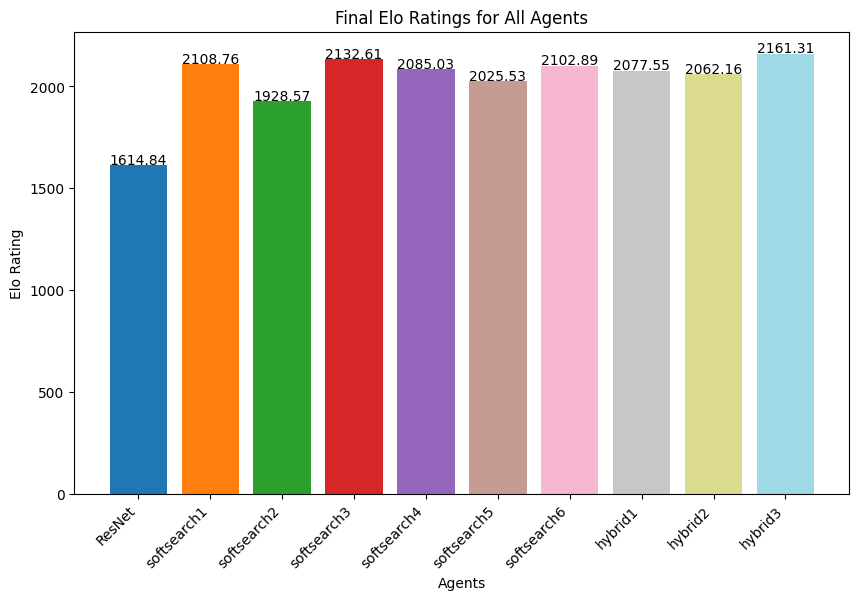

In [9]:
if torch.cuda.is_available():
    learner_device = torch.device('cuda')

run_tournament(
    seed = FLAGS.seed,
    agents = agents,
    env = eval_env,
    device = learner_device,
    num_games = 1000*len(agents),
    num_simulations = FLAGS.num_simulations,
    num_parallel = FLAGS.num_parallel,
    c_puct_base = FLAGS.c_puct_base,
    c_puct_init = FLAGS.c_puct_init,
    default_rating = FLAGS.default_rating,
    log_level = FLAGS.log_level,
    logs_dir = FLAGS.logs_dir,

)

In [12]:
elo_ratings = [round(agent_data['elo_rating'],2) for agent_data in agents.values()]
print(elo_ratings)

[1614.84, 2108.76, 1928.57, 2132.61, 2085.03, 2025.53, 2102.89, 2077.55, 2062.16, 2161.31]


In [24]:
agents_config = softsearch_configs + hybrid_configs
resnet_agent = {
    'name': 'ResNet',
    'num_res_blocks': 10,
    'num_filters_resnet': 128,
}
for agent_config in agents_config:
    agent_config.pop('load_chkpt', None)
    agent_config.pop('num_fc_units', None)
agents_config.insert(0, resnet_agent)   

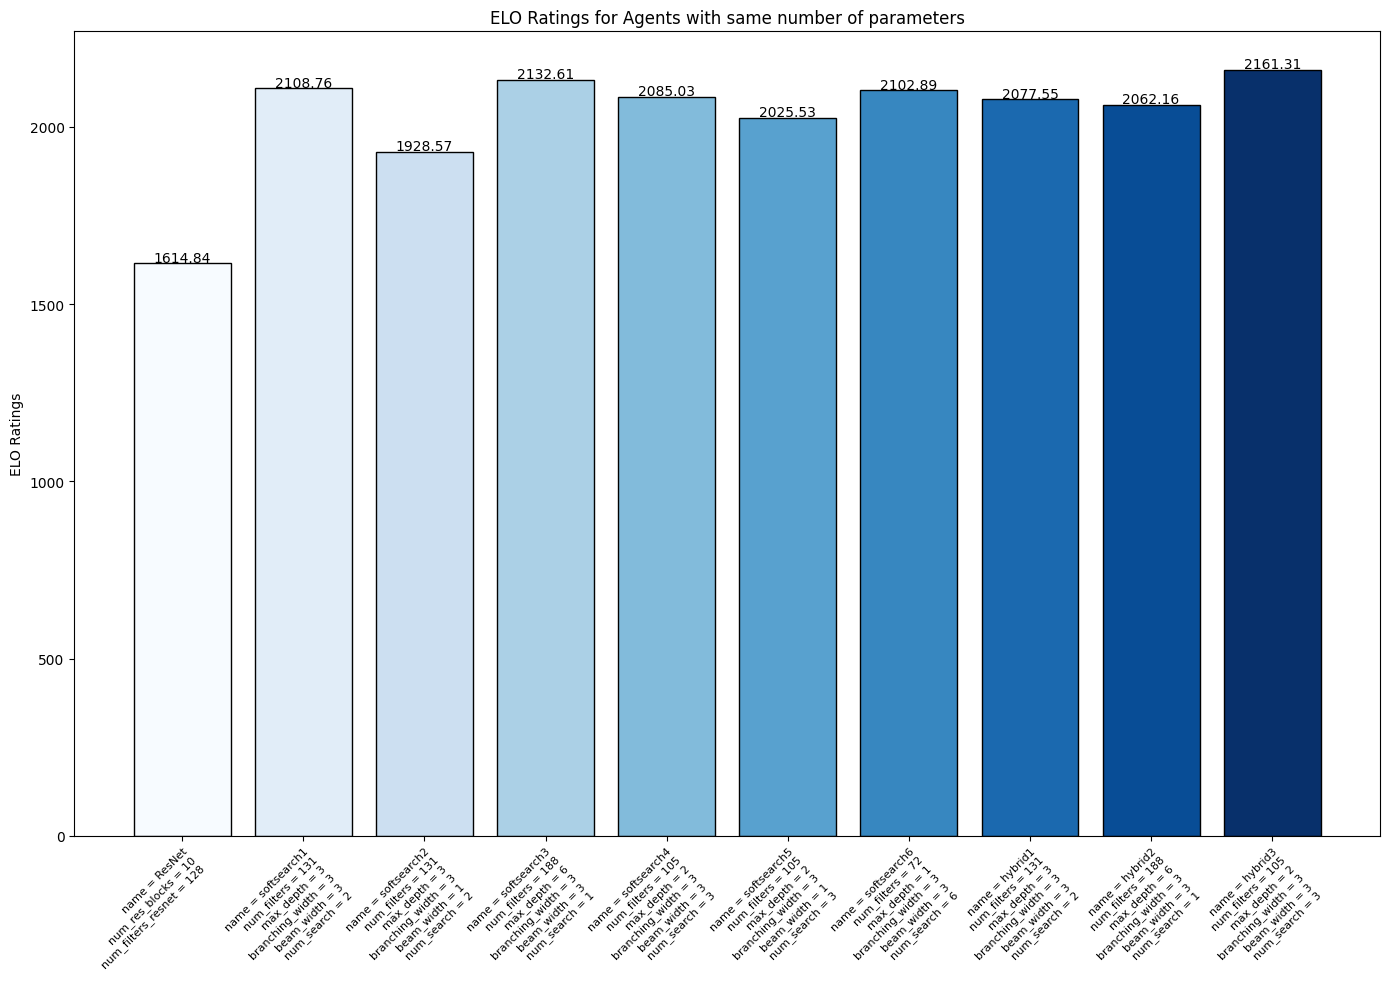

In [37]:
import matplotlib.pyplot as plt


# Prepare data for plotting
def format_agent_details(agent):
    """Format the dictionary into a multiline string for x-axis labels."""
    details = [f"{key} = {value}" for key, value in agent.items()]
    return "\n".join(details)

x_labels = [format_agent_details(agent) for agent in agents_config]  # Format as multiline strings

y_values = elo_ratings

colors = plt.cm.Blues(np.linspace(0, 1, len(x_labels)))

# Plot the bar diagram
plt.figure(figsize=(14,10))
plt.bar(range(len(x_labels)), y_values, color=colors, edgecolor='black')

# Add Elo values above the bars
for i, rating in enumerate(elo_ratings):
    plt.text(i, rating + 5, f"{rating:.2f}", ha="center", fontsize=10)
plt.ylabel("ELO Ratings")
plt.title("ELO Ratings for Agents with same number of parameters")
plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha='right', fontsize=8, wrap=True)
plt.tight_layout()
plt.show()